In [1]:
# ============================================================
# Imports
# ============================================================
!pip -q install torch-geometric
!pip -q install pandas numpy matplotlib scikit-learn tqdm
import re
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool

from tqdm import tqdm
from typing import List, Dict, Tuple, Optional

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.7 MB/s eta 0:00:00


In [2]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [3]:
seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [4]:
# -----------------------
# 2) Data loading
# -----------------------
BASE = "https://www.aflowlib.org/API/aflux/"

SELECT = (
    "$catalog(icsd),"
    "compound(*),"
    "auid(*),"
    "agl_debye(*),"
    "agl_acoustic_debye(*),"
    "ael_debye_temperature(*),"
    "agl_gruneisen(*),"
    "agl_heat_capacity_Cv_300K(*),"
    "agl_thermal_conductivity_300K(*),"
    "agl_thermal_expansion_300K(*),"
    "positions_fractional(*),"
    "geometry(*),"
    "$format(json)"
)

PER_PAGE = 500
MAX_PAGES = 15

TARGET_KEY = "agl_thermal_conductivity_300K"

GLOBAL_FEATURE_KEYS = [
    "agl_debye",
    "agl_acoustic_debye",
    "ael_debye_temperature",
    "agl_gruneisen",
    "agl_heat_capacity_Cv_300K",
    "agl_thermal_expansion_300K(*)",
]

POSITION_KEYS = ["positions_fractional", "positions_frac", "positions"]
LATTICE_KEYS  = ["lattice_vectors", "lattice", "cell"]
SPECIES_KEYS  = ["species", "elements", "atomic_symbols"]

session = requests.Session()
session.headers.update({"User-Agent": "colab-aflux-client/1.0"})

In [5]:

KNN_K = 12
EDGE_EPS = 1e-8 #so 1/d+eps cannot be infinity

BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3
VAL_RATIO = 0.1
HIDDEN = 128
DEPTH = 3


In [6]:
def fetch_page(page: int):
    """
    Fetch ONE page of AFLOW entries using aflux paging.

    Parameters
    ----------
    page : int
        Page index (1-based).

    Returns
    -------
    rows : list[dict]
        A list of AFLOW entries (JSON objects).
    url : str
        The exact URL used (for debugging / reproducibility).
    """
    url = f"{BASE}?{SELECT},$paging({page},{PER_PAGE})"

    r = session.get(url, timeout=120)
    r.raise_for_status()          # HTTP-level errors (404 / 500 / etc.)

    data = r.json()               # <-- AFLOW returns a LIST here
    if not isinstance(data, list):
        raise ValueError(
            f"Unexpected AFLOW response type: {type(data)}\nURL: {url}"
        )

    return data, url

In [7]:
def fetch_all_aflow(
    max_pages: int = MAX_PAGES,
    per_page: int = PER_PAGE,
):
    """
    Fetch all AFLOW entries using paging.
    Returns
    -------
    df : pd.DataFrame
    """
    all_rows = []
    last_url = None

    for page in tqdm(range(1, max_pages + 1), desc="Paging AFLOW"):
        rows, last_url = fetch_page(page)
        if len(rows) == 0:
            break
        all_rows.extend(rows)

    print(f"Fetched {len(all_rows)} entries.")
    print("Last URL:", last_url)
    return pd.DataFrame(all_rows)


In [8]:
df = fetch_all_aflow()

Paging AFLOW:  80%|████████  | 12/15 [00:11<00:02,  1.05it/s]

Fetched 5553 entries.
Last URL: https://www.aflowlib.org/API/aflux/?$catalog(icsd),compound(*),auid(*),agl_debye(*),agl_acoustic_debye(*),ael_debye_temperature(*),agl_gruneisen(*),agl_heat_capacity_Cv_300K(*),agl_thermal_conductivity_300K(*),agl_thermal_expansion_300K(*),positions_fractional(*),geometry(*),$format(json),$paging(13,500)


In [9]:
# ============================================================
# Periodic table
# ============================================================
PERIODIC_TABLE = {
    "H": (1, 1.008), "He": (2, 4.0026),
    "Li": (3, 6.94), "Be": (4, 9.0122), "B": (5, 10.81), "C": (6, 12.011),
    "N": (7, 14.007), "O": (8, 15.999), "F": (9, 18.998), "Ne": (10, 20.180),
    "Na": (11, 22.990), "Mg": (12, 24.305), "Al": (13, 26.982), "Si": (14, 28.085),
    "P": (15, 30.974), "S": (16, 32.06), "Cl": (17, 35.45), "Ar": (18, 39.948),
    "K": (19, 39.098), "Ca": (20, 40.078), "Sc": (21, 44.956), "Ti": (22, 47.867),
    "V": (23, 50.942), "Cr": (24, 51.996), "Mn": (25, 54.938), "Fe": (26, 55.845),
    "Co": (27, 58.933), "Ni": (28, 58.693), "Cu": (29, 63.546), "Zn": (30, 65.38),
    "Ga": (31, 69.723), "Ge": (32, 72.630), "As": (33, 74.922), "Se": (34, 78.971),
    "Br": (35, 79.904), "Kr": (36, 83.798),
    "Rb": (37, 85.468), "Sr": (38, 87.62), "Y": (39, 88.906), "Zr": (40, 91.224),
    "Nb": (41, 92.906), "Mo": (42, 95.95), "Tc": (43, 98.0), "Ru": (44, 101.07),
    "Rh": (45, 102.91), "Pd": (46, 106.42), "Ag": (47, 107.8682), "Cd": (48, 112.414),
    "In": (49, 114.818), "Sn": (50, 118.71), "Sb": (51, 121.76), "Te": (52, 127.60),
    "I": (53, 126.904), "Xe": (54, 131.293),
    "Cs": (55, 132.905), "Ba": (56, 137.327), "La": (57, 138.905), "Ce": (58, 140.116),
    "Pr": (59, 140.908), "Nd": (60, 144.242), "Pm": (61, 145.0), "Sm": (62, 150.36),
    "Eu": (63, 151.964), "Gd": (64, 157.25), "Tb": (65, 158.925), "Dy": (66, 162.50),
    "Ho": (67, 164.930), "Er": (68, 167.259), "Tm": (69, 168.934), "Yb": (70, 173.045),
    "Lu": (71, 174.967), "Hf": (72, 178.49), "Ta": (73, 180.948), "W": (74, 183.84),
    "Re": (75, 186.207), "Os": (76, 190.23), "Ir": (77, 192.217), "Pt": (78, 195.084),
    "Au": (79, 196.967), "Hg": (80, 200.592), "Tl": (81, 204.38), "Pb": (82, 207.2),
    "Bi": (83, 208.980), "Po": (84, 209.0), "At": (85, 210.0), "Rn": (86, 222.0)
}

In [10]:
# ============================================================
# Formula parsing
# ============================================================
def parse_formula(formula):
    tokens = re.findall(r"([A-Z][a-z]?)(\d*)", str(formula))

    expanded = []
    counts = {}

    for sym, num in tokens:
        n = int(num) if num else 1
        counts[sym] = counts.get(sym, 0) + n
        expanded.extend([sym] * n)

    return expanded, counts


def assign_masses(compound):
    elems, _ = parse_formula(compound)

    masses = []
    Zs = []

    for sym in elems:
        if sym not in PERIODIC_TABLE:
            raise KeyError(f"Unknown element: {sym}")

        Z, m = PERIODIC_TABLE[sym]
        Zs.append(float(Z))
        masses.append(float(m))

    return masses, Zs

In [11]:
# ============================================================
# 5) Graph building helpers
# ============================================================
def _first_existing_key(entry: dict, keys: List[str]) -> Optional[str]:
    for k in keys:
        if k in entry and entry[k] is not None:
            return k
    return None

def _wrap_frac_delta(df_: np.ndarray):
    return df_ - np.round(df_)

def _coerce_lattice(obj):
    if obj is None:
        return None
    arr = np.array(obj, dtype=float)
    if arr.shape == (3, 3):
        return arr
    if arr.size == 9:
        return arr.reshape(3, 3)
    return None

def pbc_distances(frac: np.ndarray, lattice: Optional[np.ndarray]):
    frac = np.asarray(frac, dtype=float)
    df_ = frac[None, :, :] - frac[:, None, :]
    df_ = _wrap_frac_delta(df_)
    dvec = df_ if lattice is None else (df_ @ np.asarray(lattice, dtype=float))
    return np.linalg.norm(dvec, axis=-1)

# ============================================================
# Build edges
# ============================================================
def assign_edges(frac, lattice, k=12):
    N = len(frac)
    D = pbc_distances(frac, lattice)

    src = []
    dst = []
    dist = []

    for i in range(N):
        idx = np.argsort(D[i])
        idx = idx[idx != i]

        for j in idx[:min(k, len(idx))]:
            src.append(i)
            dst.append(int(j))
            dist.append(float(D[i, j]))

    edge_index = torch.tensor([src, dst], dtype=torch.long)

    dist = np.array(dist, dtype=float)
    inv_dist = 1.0 / (dist + EDGE_EPS)

    edge_attr = torch.tensor(
        np.stack([dist, inv_dist], axis=1),
        dtype=torch.float32
    )

    return edge_index, edge_attr

In [12]:
# ============================================================
# Build graph from AFLOW entry (graph-only)
# ============================================================
def build_graph_from_entry(entry: dict, k: int = 12):
    pos_key = _first_existing_key(entry, POSITION_KEYS)
    if pos_key is None:
        raise KeyError(f"No positions key found. Tried {POSITION_KEYS}")

    frac = np.array(entry[pos_key], dtype=float)
    if frac.ndim != 2 or frac.shape[1] != 3:
        raise ValueError(f"Positions {pos_key} has invalid shape: {frac.shape}")

    lat_key = _first_existing_key(entry, LATTICE_KEYS)
    lattice = _coerce_lattice(entry.get(lat_key)) if lat_key else None

    species_key = _first_existing_key(entry, SPECIES_KEYS)

    if species_key is not None:
        species = list(entry[species_key])
        Zs, masses = [], []

        for s in species:
            if s not in PERIODIC_TABLE:
                raise KeyError(f"Unknown species: {s}")
            Z, m = PERIODIC_TABLE[s]
            Zs.append(float(Z))
            masses.append(float(m))
    else:
        if "compound" not in entry or entry["compound"] is None:
            raise KeyError("compound missing")
        masses, Zs = assign_masses(entry["compound"])

    n_sites = len(frac)

    if len(Zs) != n_sites:
        if len(Zs) < n_sites:
            reps = int(np.ceil(n_sites / len(Zs)))
            Zs = (Zs * reps)[:n_sites]
            masses = (masses * reps)[:n_sites]
        else:
            Zs = Zs[:n_sites]
            masses = masses[:n_sites]

    x = torch.tensor(
        np.stack([Zs, masses], axis=1),
        dtype=torch.float32
    )

    edge_index, edge_attr = assign_edges(frac, lattice, k=k)

    y_raw = float(entry[TARGET_KEY])
    y = torch.tensor([[np.log1p(y_raw)]], dtype=torch.float32)

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y
    )

    data.compound = str(entry.get("compound", "unknown"))
    data.auid = str(entry.get("auid", "unknown"))

    return data

In [13]:
# ============================================================
# DataFrame to graphs
# ============================================================
from typing import Optional
def df_to_graphs(df: pd.DataFrame, k: int = 12, limit: Optional[int] = None):
    graphs, skipped = [], []
    n = len(df) if limit is None else min(len(df), limit)

    for i in tqdm(range(n), desc="Building graphs"):
        entry = df.iloc[i].to_dict()
        try:
            graphs.append(build_graph_from_entry(entry, k=k))
        except Exception as e:
            skipped.append((i, str(e)))

    print(f"Built graphs: {len(graphs)} / {n}, skipped: {len(skipped)}")
    return graphs, skipped

In [14]:
graphs, skipped = df_to_graphs(df, k=KNN_K)

Building graphs: 100%|██████████| 5553/5553 [00:06<00:00, 821.18it/s]

Built graphs: 5320 / 5553, skipped: 233


In [15]:
# ============================================================
# Split dataset
# ============================================================
idx = list(range(len(graphs)))
random.shuffle(idx)
TEST_RATIO = 0.1
n = len(idx)
n_test = int(n * TEST_RATIO)
n_val = int(n * VAL_RATIO)

train = [graphs[i] for i in idx[:n - n_val - n_test]]
val   = [graphs[i] for i in idx[n - n_val - n_test:n - n_test]]
test  = [graphs[i] for i in idx[n - n_test:]]

In [16]:
len(graphs), len(train), len(val), len(test), len(skipped)

(5320, 4256, 532, 532, 233)

In [17]:
# ============================================================
# Feature scaling
# ============================================================
def fit_scalers(train_graphs):
    mass = torch.cat([g.x[:, 1] for g in train_graphs]).float()
    mass_mu = mass.mean().item()
    mass_std = mass.std(unbiased=False).item()
    if mass_std < 1e-12:
        mass_std = 1.0

    edge_all = torch.cat([g.edge_attr for g in train_graphs], dim=0).float()
    edge_mu = edge_all.mean(dim=0)
    edge_std = edge_all.std(dim=0, unbiased=False)
    edge_std[edge_std < 1e-12] = 1.0

    return {
        "mass_mu": mass_mu,
        "mass_std": mass_std,
        "edge_mu": edge_mu,
        "edge_std": edge_std
    }


def apply_scalers(graphs, scalers):
    for g in graphs:
        Z = g.x[:, 0:1] / 100.0
        mass = g.x[:, 1:2]
        mass = (mass - scalers["mass_mu"]) / scalers["mass_std"]
        g.x = torch.cat([Z, mass], dim=1)

        g.edge_attr = (g.edge_attr - scalers["edge_mu"]) / scalers["edge_std"]


scalers = fit_scalers(train)
apply_scalers(train, scalers)
apply_scalers(val, scalers)
apply_scalers(test, scalers)

In [18]:
# ============================================================
# Message passing layer
# ============================================================
class EdgeMP(MessagePassing):
    def __init__(self, x_dim, e_dim, hidden):
        super().__init__(aggr="add")

        self.msg = nn.Sequential(
            nn.Linear(x_dim + e_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )

        self.upd = nn.Sequential(
            nn.Linear(x_dim + hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )

        self.res = nn.Linear(x_dim, hidden)

    def forward(self, x, edge_index, edge_attr):
        m = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        out = self.upd(torch.cat([x, m], dim=-1))
        return out + self.res(x)

    def message(self, x_j, edge_attr):
        return self.msg(torch.cat([x_j, edge_attr], dim=-1))

In [19]:
# ============================================================
# Graph-only GNN regressor
# ============================================================
class GraphOnlyRegressor(nn.Module):
    def __init__(self, x_dim, e_dim, hidden=128, depth=3):
        super().__init__()

        self.layers = nn.ModuleList([
            EdgeMP(x_dim if i == 0 else hidden, e_dim, hidden)
            for i in range(depth)
        ])

        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, 1)
        )

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        edge_attr = data.edge_attr
        batch = data.batch

        for layer in self.layers:
            x = layer(x, edge_index, edge_attr)

        g = global_mean_pool(x, batch)
        out = self.head(g)

        return out

In [20]:
# ============================================================
# Train model
# ============================================================
def train_model(train, val, epochs=10, batch_size=32, lr=1e-3):
    train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val, batch_size=batch_size, shuffle=False)

    g0 = train[0]

    model = GraphOnlyRegressor(
        x_dim=g0.x.size(-1),
        e_dim=g0.edge_attr.size(-1),
        hidden=128,
        depth=3
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    history = {"train": [], "val": []}
    best_val = float("inf")
    best_state = None

    for epoch in range(epochs):
        model.train()
        train_loss_sum = 0.0

        for batch in train_loader:
            batch = batch.to(device)

            opt.zero_grad()
            pred = model(batch).view(-1)
            y = batch.y.view(-1)

            loss = loss_fn(pred, y)
            loss.backward()
            opt.step()

            train_loss_sum += loss.item()

        train_loss = train_loss_sum / len(train_loader)

        model.eval()
        val_loss_sum = 0.0

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                pred = model(batch).view(-1)
                y = batch.y.view(-1)
                val_loss_sum += loss_fn(pred, y).item()

        val_loss = val_loss_sum / len(val_loader)

        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)


    return model, history

In [21]:
model, history = train_model(
    train,
    val,
    epochs=10,
    batch_size=32,
    lr=1e-3
)

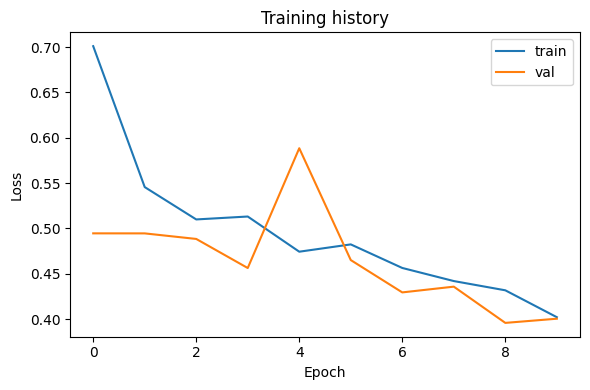

In [22]:
# ============================================================
# Plot history
# ============================================================
plt.figure(figsize=(6, 4))
plt.plot(history["train"], label="train")
plt.plot(history["val"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training history")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# Test evaluation
# ============================================================
test_loader = DataLoader(test, batch_size=BATCH_SIZE, shuffle=False)


model.eval()

true = []
pred = []
compounds = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)

        p = model(batch).view(-1).cpu().numpy()
        y = batch.y.view(-1).cpu().numpy()

        true.append(y)
        pred.append(p)

        if hasattr(batch, "compound"):
            if isinstance(batch.compound, list):
                compounds.extend(batch.compound)
            else:
                compounds.extend([batch.compound] * len(y))
        else:
            compounds.extend(["unknown"] * len(y))

true = np.concatenate(true)
pred = np.concatenate(pred)

In [24]:
metrics_df = pd.DataFrame([{
    "MAE_log": mean_absolute_error(true, pred),
    "RMSE_log": np.sqrt(mean_squared_error(true, pred)),
    "R2_log": r2_score(true, pred),
    "MAE_kappa": mean_absolute_error(np.expm1(true), np.expm1(pred)),
    "RMSE_kappa": np.sqrt(mean_squared_error(np.expm1(true), np.expm1(pred))),
    "R2_kappa": r2_score(np.expm1(true), np.expm1(pred))
}])

metrics_df

,MAE_log,RMSE_log,R2_log,MAE_kappa,RMSE_kappa,R2_kappa
0,0.493988,0.615871,0.478446,4.167634,8.964985,0.389066


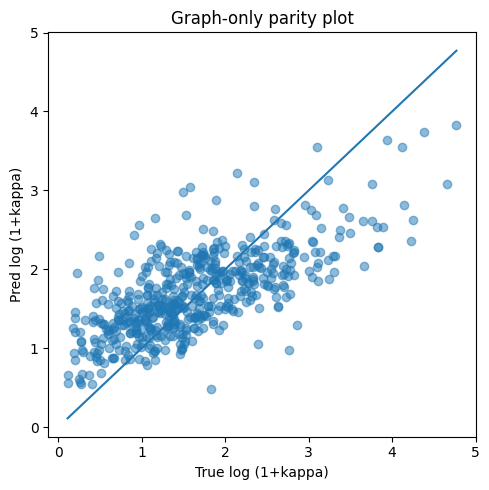

In [35]:
# ============================================================
# Parity plot
# ============================================================
plt.figure(figsize=(5, 5))
plt.scatter(true, pred, alpha=0.5)

lo = min(true.min(), pred.min())
hi = max(true.max(), pred.max())

plt.plot([lo, hi], [lo, hi])
plt.xlabel("True log (1+kappa)")
plt.ylabel("Pred log (1+kappa)")
plt.title("Graph-only parity plot")
plt.tight_layout()
plt.show()

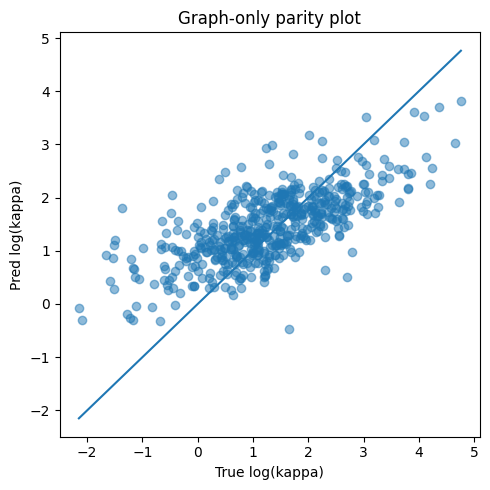

In [37]:
# ============================================================
# Convert to log(kappa)
# ============================================================
true_kappa = np.expm1(true)
pred_kappa = np.expm1(pred)

# avoid log(0)
eps = 1e-8
true_logk = np.log(true_kappa + eps)
pred_logk = np.log(pred_kappa + eps)

# ============================================================
# Parity plot (log kappa)
# ============================================================
plt.figure(figsize=(5, 5))

plt.scatter(true_logk, pred_logk, alpha=0.5)

lo = min(true_logk.min(), pred_logk.min())
hi = max(true_logk.max(), pred_logk.max())

plt.plot([lo, hi], [lo, hi])

plt.xlabel("True log(kappa)")
plt.ylabel("Pred log(kappa)")
plt.title("Graph-only parity plot")

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# Save outputs
# ============================================================
history_df = pd.DataFrame({
    "epoch": np.arange(1, len(history["train"]) + 1),
    "train_loss": history["train"],
    "val_loss": history["val"]
})

pred_df = pd.DataFrame({
    "compound": compounds,
    "true_log_kappa": true,
    "pred_log_kappa": pred,
    "true_kappa": np.expm1(true),
    "pred_kappa": np.expm1(pred),
    "abs_error_log": np.abs(true - pred)
})

history_df.to_csv("graph_only_history.csv", index=False)
pred_df.to_csv("graph_only_predictions.csv", index=False)
metrics_df.to_csv("graph_only_metrics.csv", index=False)

In [27]:
# ============================================================
# Train helper with custom epochs
# ============================================================
def train_model_with_epochs(train, val, epochs, batch_size=32, lr=1e-3, model_save_path=None):

    train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val, batch_size=batch_size, shuffle=False)

    g0 = train[0]

    model = GraphOnlyRegressor(
        x_dim=g0.x.size(-1),
        e_dim=g0.edge_attr.size(-1),
        hidden=128,
        depth=3
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    history = {"epoch": [], "train": [], "val": []}

    best_val = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):

        model.train()
        train_loss_sum = 0.0

        for batch in train_loader:

            batch = batch.to(device)

            opt.zero_grad()

            pred = model(batch).view(-1)
            y = batch.y.view(-1)

            loss = loss_fn(pred, y)

            loss.backward()

            opt.step()

            train_loss_sum += loss.item()

        train_loss = train_loss_sum / len(train_loader)

        model.eval()

        val_loss_sum = 0.0

        with torch.no_grad():

            for batch in val_loader:

                batch = batch.to(device)

                pred = model(batch).view(-1)
                y = batch.y.view(-1)

                val_loss_sum += loss_fn(pred, y).item()

        val_loss = val_loss_sum / len(val_loader)

        history["epoch"].append(epoch)
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if val_loss < best_val:

            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    if model_save_path is not None:
        torch.save(best_state, model_save_path)

    return model, history

In [28]:
# ============================================================
# Evaluation helper
# ============================================================
def evaluate_model(model, test, batch_size=32):

    test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

    model.eval()

    true = []
    pred = []
    compounds = []

    with torch.no_grad():

        for batch in test_loader:

            batch = batch.to(device)

            p = model(batch).view(-1).cpu().numpy()
            y = batch.y.view(-1).cpu().numpy()

            true.append(y)
            pred.append(p)

            if hasattr(batch, "compound"):

                if isinstance(batch.compound, list):
                    compounds.extend(batch.compound)
                else:
                    compounds.extend([batch.compound] * len(y))

            else:

                compounds.extend(["unknown"] * len(y))

    true = np.concatenate(true)
    pred = np.concatenate(pred)

    metrics = {

        "MAE_log": mean_absolute_error(true, pred),
        "RMSE_log": np.sqrt(mean_squared_error(true, pred)),
        "R2_log": r2_score(true, pred),

        "MAE_kappa": mean_absolute_error(np.expm1(true), np.expm1(pred)),
        "RMSE_kappa": np.sqrt(mean_squared_error(np.expm1(true), np.expm1(pred))),
        "R2_kappa": r2_score(np.expm1(true), np.expm1(pred)),
    }

    pred_df = pd.DataFrame({

        "compound": compounds,
        "true_log_kappa": true,
        "pred_log_kappa": pred,
        "true_kappa": np.expm1(true),
        "pred_kappa": np.expm1(pred),
        "abs_error_log": np.abs(true - pred)

    })

    return metrics, pred_df

In [29]:
# ============================================================
# Epoch comparison experiment
# ============================================================
epoch_list = [10, 20, 30]

epoch_results = {}

history_dfs = []
metrics_rows = []
pred_dfs = []

for ep in epoch_list:

    model_ep, history_ep = train_model_with_epochs(

        train=train,
        val=val,
        epochs=ep,
        batch_size=BATCH_SIZE,
        lr=LR,
        model_save_path=f"best_graph_only_model_{ep}epochs.pt"

    )

    metrics_ep, pred_df_ep = evaluate_model(

        model=model_ep,
        test=test,
        batch_size=BATCH_SIZE

    )

    history_df_ep = pd.DataFrame({

        "epoch": history_ep["epoch"],
        "train_loss": history_ep["train"],
        "val_loss": history_ep["val"],
        "max_epochs": ep

    })

    metrics_row = {

        "max_epochs": ep,
        **metrics_ep

    }

    pred_df_ep["max_epochs"] = ep

    epoch_results[ep] = {

        "model": model_ep,
        "history": history_ep,
        "metrics": metrics_ep,
        "pred_df": pred_df_ep

    }

    history_dfs.append(history_df_ep)
    metrics_rows.append(metrics_row)
    pred_dfs.append(pred_df_ep)

In [30]:
# ============================================================
# Combine comparison data
# ============================================================
epoch_history_df = pd.concat(history_dfs, ignore_index=True)
epoch_metrics_df = pd.DataFrame(metrics_rows)
epoch_pred_df = pd.concat(pred_dfs, ignore_index=True)

epoch_metrics_df

,max_epochs,MAE_log,RMSE_log,R2_log,MAE_kappa,RMSE_kappa,R2_kappa
0,10,0.466327,0.599155,0.506374,4.058583,9.013655,0.382415
1,20,0.410574,0.541887,0.596228,3.596045,7.619657,0.558668
2,30,0.331858,0.455983,0.714098,3.169693,8.193415,0.489701


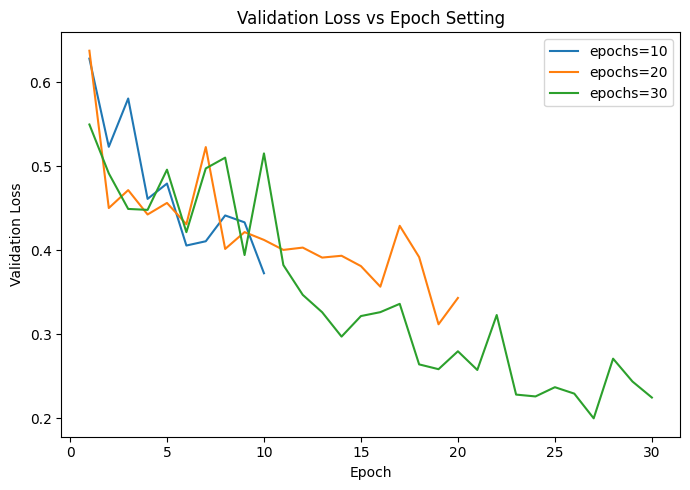

In [31]:
# ============================================================
# Plot validation loss comparison
# ============================================================
plt.figure(figsize=(7,5))

for ep in epoch_list:

    sub = epoch_history_df[epoch_history_df["max_epochs"] == ep]

    plt.plot(sub["epoch"], sub["val_loss"], label=f"epochs={ep}")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch Setting")
plt.legend()

plt.tight_layout()
plt.show()

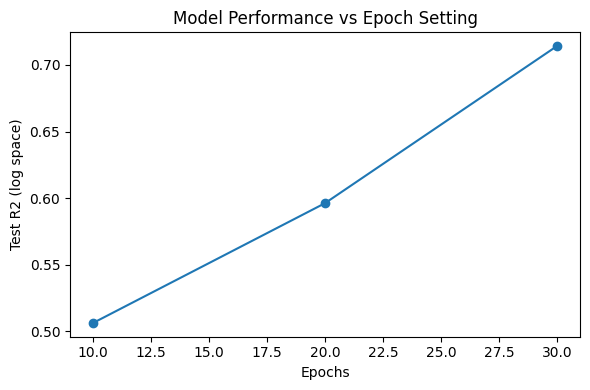

In [32]:
# ============================================================
# Plot R2 comparison
# ============================================================
plt.figure(figsize=(6,4))

plt.plot(epoch_metrics_df["max_epochs"], epoch_metrics_df["R2_log"], marker="o")

plt.xlabel("Epochs")
plt.ylabel("Test R2 (log space)")
plt.title("Model Performance vs Epoch Setting")

plt.tight_layout()
plt.show()

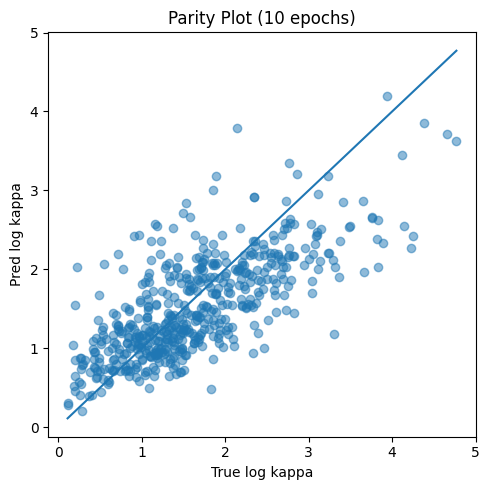

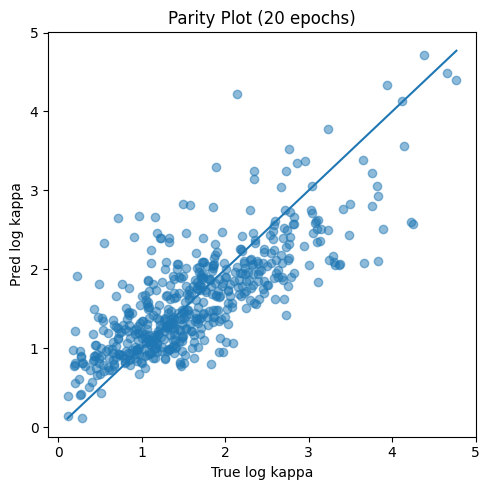

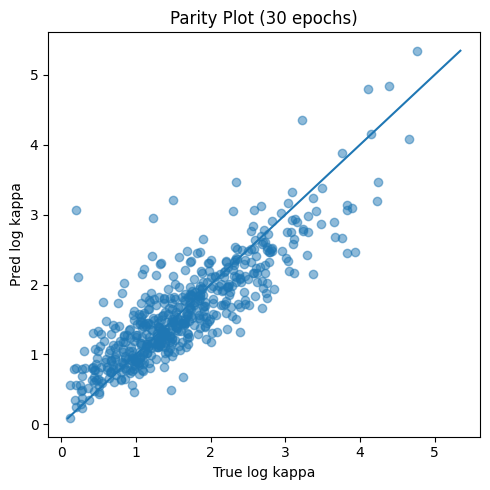

In [33]:
# ============================================================
# Parity plots
# ============================================================
for ep in epoch_list:

    pred_df_ep = epoch_results[ep]["pred_df"]

    true_ep = pred_df_ep["true_log_kappa"].values
    pred_ep = pred_df_ep["pred_log_kappa"].values

    plt.figure(figsize=(5,5))

    plt.scatter(true_ep, pred_ep, alpha=0.5)

    lo = min(true_ep.min(), pred_ep.min())
    hi = max(true_ep.max(), pred_ep.max())

    plt.plot([lo,hi],[lo,hi])

    plt.xlabel("True log kappa")
    plt.ylabel("Pred log kappa")

    plt.title(f"Parity Plot ({ep} epochs)")

    plt.tight_layout()
    plt.show()

In [34]:
# ============================================================
# Save comparison results
# ============================================================
epoch_history_df.to_csv("epoch_comparison_history.csv", index=False)
epoch_metrics_df.to_csv("epoch_comparison_metrics.csv", index=False)
epoch_pred_df.to_csv("epoch_comparison_predictions.csv", index=False)